## Study takeaway (read first)

**Topic:** NLTK tokenization + BPE + Zipf's law (Lecture 1)

**Walkthrough:** Gutenberg book -> clean text -> word tokens -> types vs tokens (TTR) -> frequency plot (Zipf) -> compare Voynich manuscript -> train BPE on both.

**Remember for exam:** BPE merges most frequent pairs; subwords fix OOV. Zipf = few very frequent words, long tail. Types=unique, tokens=total.

**Time:** ~1h skim | **Exam priority:** Low

![MSE Logo](https://moodle.msengineering.ch/pluginfile.php/1/core_admin/logo/0x150/1643104191/logo-mse.png)

# AdvNLP Lab 1: Text Tokenization

**Authors:**
- Diego Gil Cordeiro (diego.gilcordeiro@students.bfh.ch)
- Rajilatha Kandiah (rajilatha.rajendiram@students.bfh.ch)

---

The goal of this lab is to perform tokenization of texts using the [NLTK](http://www.nltk.org/) toolkit or using BPE from [SentencePiece](https://github.com/google/sentencepiece).  You will use the environment that you set up following the instructions of the introductory Jupyter notebook.  

You will use NLTK functions to get texts from the web and segment (split) them into sentences and words (also called *tokens*).  You will experiment with extracting statistics about the frequencies of tokens, and compare statistics for a novel and an undeciphered manuscript. 

To submit your work, please execute all cells of this notebook, save it, and submit it as homework on Moodle.

## 1. Using NLTK to download and tokenize a text

Please install NLTK (the Natural Language Processing Toolkit) by following the installation instructions at the [NLTK website](http://www.nltk.org/install.html).  To use NLTK, first `import nltk`.  NLTK has a download manager (try `nltk.download()` in command line) which can import several resources, including corpora.

To get started, look at [Chapter 1](http://www.nltk.org/book/ch01.html) of the [online NLTK book (NLP with Python)](http://www.nltk.org/book/) and use the commands there as a model.  <span style="color:gray">Note: the online book was updated for Python 3, but the [printed book](http://shop.oreilly.com/product/9780596516499.do) is only for Python 2.</span> 

In [60]:
import nltk
# nltk.download('punkt') # execute only once after installing NLTK, then comment it out

**1a.** Using inspiration from [Chapter 3 (3.1. Processing Raw Text) of the NLTK book](http://www.nltk.org/book/ch03.html), download a book from the Gutenberg Project in text format. What is its size? Are these bytes or characters? <span style="color:gray">Note: to learn more about special characters, you can refer to Python's documentation of [Unicode support](https://docs.python.org/3/howto/unicode.html).</span>

In [61]:
from urllib import request # you may need to run first:  !pip install urllib

In [62]:
# downloading Pride and Prejudice from gutenberg
url = "https://www.gutenberg.org/files/1342/1342-0.txt"
response = request.urlopen(url)
raw = response.read().decode('utf8')

print("Size:", len(raw))
# these are characters since we decoded utf8, not bytes
print(raw[:500])


Size: 728846
*** START OF THE PROJECT GUTENBERG EBOOK 1342 ***




                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                             RUSKIN HOUSE
                                   ]

                            [Illustration:

               _Reading Jane’s Letters._      _Chap 34._
                                   ]




         


**1b.** We want to keep only the original text of the book, without the header, preface, or license.  Please determine (e.g. by locating the position of initial and final strings) how much your should trim from the beginning and from the end in order to keep only the original text of the book (including titles). Please remove unnecessary paragraph marks (e.g. if the text is segmented into fixed-length lines). Save the result as a new string and display its length.

In [63]:
import re

# find where the actual content starts/ends
start = raw.find("*** START OF THE PROJECT GUTENBERG EBOOK")
end = raw.find("*** END OF THE PROJECT GUTENBERG EBOOK")
book_text = raw[start:end]

# skip to chapter 1 to avoid preface stuff
ch1 = book_text.find("CHAPTER I")
if ch1 != -1:
    book_text = book_text[ch1:]

# clean up formatting: remove _ (used for italics), [Illustration] tags, fix whitespace
book_text = re.sub(r'_', '', book_text)
book_text = re.sub(r'\[Illustration[^\]]*\]', '', book_text)
book_text = re.sub(r' +', ' ', book_text)
book_text = re.sub(r'\n\n+', '\n\n', book_text)
book_text = re.sub(r'(?<!\n)\n(?!\n)', ' ', book_text)
book_text = book_text.strip()

print(f"Cleaned text length: {len(book_text)}")
print(book_text[:500])


Cleaned text length: 681050
CHAPTER II.

Mr. Bennet was among the earliest of those who waited on Mr. Bingley. He had always intended to visit him, though to the last always assuring his wife that he should not go; and till the evening after the visit was paid she had no knowledge of it. It was then disclosed in the following manner. Observing his second daughter employed in trimming a hat, he suddenly addressed her with,--

“I hope Mr. Bingley will like it, Lizzy.”

“We are not in a way to know what Mr. Bingley likes,” sa


**1c.** NLTK defines a function to segment a text into sentences (`nltk.sent_tokenize(...)` (documented [here](https://www.nltk.org/api/nltk.tokenize.html#nltk.tokenize.word_tokenize))) and another one to tokenize a text into words (`nltk.word_tokenize(...)` (documented [here](https://www.nltk.org/api/nltk.tokenize.html#nltk.tokenize.sent_tokenize))). <span style="color:gray">Note: NLTK calls the first one "sentence tokenization", which is unusual.</span>

Please segment the text above into sentences with NLTK, display the number of sentences, and display five sentences of your choice.  Please assess briefly the quality of the segmentation.  If you think that some special characters degrade the results, please go back and remove or replace them in the full text.

In [64]:
nltk.download('punkt_tab')

sentences = nltk.sent_tokenize(book_text)
print(f"Found {len(sentences)} sentences")

# show a few examples
for i in range(10, 15):
    print(f"\n[{i}]: {sentences[i]}")

# the segmentation looks pretty good - handles Mr. and Mrs. correctly without splitting there


Found 4618 sentences

[10]: “When is your next ball to be, Lizzy?”

“To-morrow fortnight.”

“Ay, so it is,” cried her mother, “and Mrs. Long does not come back till the day before; so, it will be impossible for her to introduce him, for she will not know him herself.”

“Then, my dear, you may have the advantage of your friend, and introduce Mr. Bingley to her.”

“Impossible, Mr. Bennet, impossible, when I am not acquainted with him myself; how can you be so teasing?”

“I honour your circumspection.

[11]: A fortnight’s acquaintance is certainly very little.

[12]: One cannot know what a man really is by the end of a fortnight.

[13]: But if we do not venture, somebody else will; and after all, Mrs. Long and her nieces must stand their chance; and, therefore, as she will think it an act of kindness, if you decline the office, I will take it on myself.”

The girls stared at their father.

[14]: Mrs. Bennet said only, “Nonsense, nonsense!”

“What can be the meaning of that emphatic exclam

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\info\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


**1d.** Please save the resulting text into a file, one sentence per line.

In [65]:
with open("book_sentences.txt", 'w', encoding='utf-8') as f:
    for s in sentences:
        f.write(s + '\n')
print("saved to book_sentences.txt")

saved to book_sentences.txt


**1e.** Please segment each sentence into tokens,  store the result in a new variable (a list of lists), and display the same five sentences as above.  Please comment briefly on the quality of the tokenization.

In [66]:
tokenized_sentences = [nltk.word_tokenize(s) for s in sentences]

# same sentences as before but now as token lists
for i in range(10, 15):
    print(f"[{i}]: {tokenized_sentences[i]}")

# punctuation gets its own tokens, contractions split into parts (don't -> do + n't)


[10]: ['“', 'When', 'is', 'your', 'next', 'ball', 'to', 'be', ',', 'Lizzy', '?', '”', '“', 'To-morrow', 'fortnight.', '”', '“', 'Ay', ',', 'so', 'it', 'is', ',', '”', 'cried', 'her', 'mother', ',', '“', 'and', 'Mrs.', 'Long', 'does', 'not', 'come', 'back', 'till', 'the', 'day', 'before', ';', 'so', ',', 'it', 'will', 'be', 'impossible', 'for', 'her', 'to', 'introduce', 'him', ',', 'for', 'she', 'will', 'not', 'know', 'him', 'herself.', '”', '“', 'Then', ',', 'my', 'dear', ',', 'you', 'may', 'have', 'the', 'advantage', 'of', 'your', 'friend', ',', 'and', 'introduce', 'Mr.', 'Bingley', 'to', 'her.', '”', '“', 'Impossible', ',', 'Mr.', 'Bennet', ',', 'impossible', ',', 'when', 'I', 'am', 'not', 'acquainted', 'with', 'him', 'myself', ';', 'how', 'can', 'you', 'be', 'so', 'teasing', '?', '”', '“', 'I', 'honour', 'your', 'circumspection', '.']
[11]: ['A', 'fortnight', '’', 's', 'acquaintance', 'is', 'certainly', 'very', 'little', '.']
[12]: ['One', 'can', 'not', 'know', 'what', 'a', 'man', '

**1f.** Please display the total number of tokens found in the text by this method (sentence segmentation followed by sentence-level tokenization).

In [67]:
total_tokens_sent = sum(len(s) for s in tokenized_sentences)
print(f"Total tokens (sentence-by-sentence): {total_tokens_sent}")


Total tokens (sentence-by-sentence): 142911


**1g.** Please tokenize now directly the initial full text, without segmenting it into sentences.  Please display the total number of tokens found, and compare this number with the one obtained above.

In [68]:
# now try tokenizing the whole text at once
tokens_direct = nltk.word_tokenize(book_text)

print(f"Direct tokenization: {len(tokens_direct)}")
print(f"Via sentences: {total_tokens_sent}")
print(f"Difference: {abs(len(tokens_direct) - total_tokens_sent)}")
# basically the same - makes sense since word_tokenize uses same rules either way


Direct tokenization: 142911
Via sentences: 142911
Difference: 0


## 2. Computing lexical statistics 

**2a.** Please determine the size of the vocabulary of your text (the number of unique *types*) by converting the list of tokens to a Python `set`.  Note that these *types* include punctuations and other symbols found through tokenization, and that uppercase/lowercase letters are different.

In [69]:
vocab = set(tokens_direct)
print(f"Types (unique): {len(vocab)}")
print(f"Tokens (total): {len(tokens_direct)}")


Types (unique): 7287
Tokens (total): 142911


**2b.** What is the type-to-token ratio (TTR) of your text?

In [70]:
ttr = len(vocab) / len(tokens_direct)
print(f"TTR: {ttr:.4f}")
# low TTR = lots of repetition, which is normal for longer texts


TTR: 0.0510


**2c.** Please create a `nltk.Text` object from the tokenized version of your text, without the sentence segmentation.  Such an object will enable you to compute statistics using NLTK functions.  [Chapter 1 of the NLTK book](http://www.nltk.org/book/ch01.html) provides examples of use.

<span style="color:gray">Note: `nltk.word_tokenize()` and `nltk.sent_tokenize()` apply to strings but not directly to `ntlk.Text` objects.  A `nltk.Text` object can store either a string, or a list of words, or a list of sentences (list of lists of strings).</span>

In [71]:
text_obj = nltk.Text(tokens_direct)
print(text_obj[:20])


['CHAPTER', 'II', '.', 'Mr.', 'Bennet', 'was', 'among', 'the', 'earliest', 'of', 'those', 'who', 'waited', 'on', 'Mr.', 'Bingley', '.', 'He', 'had', 'always']


**2d.** Please construct the frequency distribution of your text, which is an object of the `nltk.FreqDist`class, instantiated directly from the `nltk.Text` object containing the list of all words. See [Sec. 3.1 of Ch. 1 of the NLTK book](http://www.nltk.org/book/ch01.html#frequency-distributions).  Using the `most_common` method on the `FreqDist` object, find the 50 most frequent words in your text, and display among them the words that have at least 4 characters.  Please comment briefly on the results.

In [72]:
freq_dist = nltk.FreqDist(text_obj)
top50 = freq_dist.most_common(50)
print(top50)

# filter to 4+ char words
print("\n4+ character words:")
for word, count in top50:
    if len(word) >= 4:
        print(f"  {word}: {count}")
# mostly function words (that, with, have) plus character names like Elizabeth


[(',', 9440), ('to', 4069), ('.', 4059), ('the', 4045), ('of', 3582), ('and', 3416), ('her', 2122), ('I', 2053), ('a', 1879), ('was', 1834), ('in', 1765), ('“', 1735), ('”', 1703), (';', 1653), ('that', 1522), ('not', 1493), ('she', 1381), ('it', 1252), ('be', 1222), ('his', 1179), ('had', 1143), ('as', 1121), ('you', 1111), ('he', 1090), ('for', 1029), ('with', 1014), ('have', 829), ('is', 819), ('Mr.', 757), ('at', 738), ('him', 734), ('’', 730), ('but', 695), ('on', 680), ('s', 641), ('Elizabeth', 633), ('by', 614), ('all', 596), ('my', 594), ('so', 575), ('were', 559), ('which', 541), ('could', 513), ('been', 513), ('they', 475), ('from', 472), ('very', 471), ('--', 466), ('?', 465), ('would', 465)]

4+ character words:
  that: 1522
  with: 1014
  have: 829
  Elizabeth: 633
  were: 559
  which: 541
  could: 513
  been: 513
  they: 475
  from: 472
  very: 471
  would: 465


## 3. Testing Zipf's law on a book

[Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law) formalizes the following empirical observation for large texts or collections: when ranking word types by decreasing frequencies, the ranks *x* (i.e. 1, 2, 3, ...) and the numbers of occurrences *y* (e.g. 948, 321, 146, ...) of each word are related approximately by the formula *y = a / x^b*.  The parameters *a* and *b* depend on the text.  If plotted in log-log coordinates, this relation results in a linear plot (because log(*y*) = *a* - *b* log(*x*)).

**3a.** Using the `FreqDist` object, please collect the frequencies of the 1000 most frequent words, rank them by decreasing values, and plot the (*rank*, *frequency*) curve on a log-log scale by setting the `.xscale("log")` and `.yscale("log")` parameters of the plot.

In [73]:
import matplotlib.pyplot as plt
%matplotlib inline

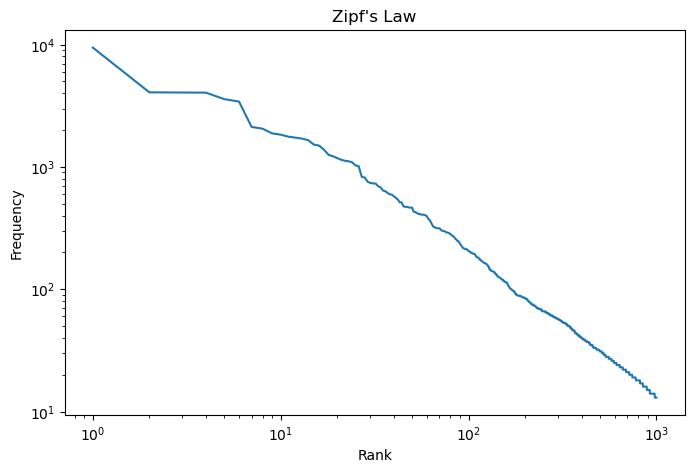

In [74]:
top1000 = freq_dist.most_common(1000)
ranks = range(1, len(top1000) + 1)
freqs = [c for w, c in top1000]

plt.figure(figsize=(8, 5))
plt.plot(ranks, freqs)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title("Zipf's Law")
plt.show()


**3b.** Please find the values of *a* and *b* which lead to the closest matching between the observation curve (*rank*, *frequency*) and Zipf's curve (*x*, *y = a / x^b*).  You can use `scipy.optimize.curve_fit()` or even a trial-and-error approach.  Please display both curves on the same graph with a log-log scale to visualize how close they are.  Please also display the optimal values of *a* and *b*.

In [75]:
import numpy as np 
import scipy

a = 9583.97, b = 0.7813


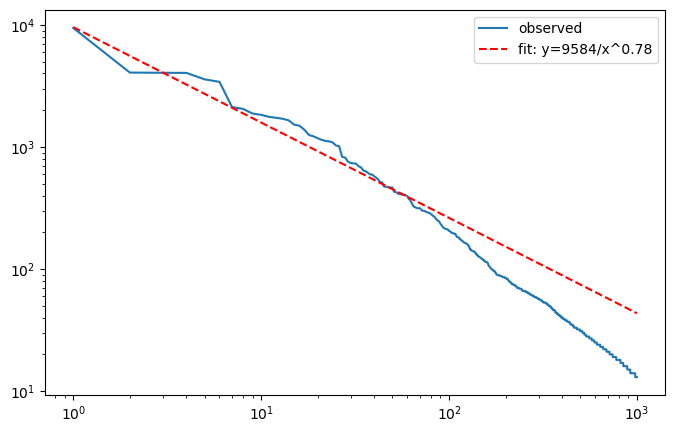

MAPE: 132.0%


In [76]:
from scipy.optimize import curve_fit

def zipf(x, a, b):
    return a / np.power(x, b)

ranks_arr = np.array(list(ranks))
freqs_arr = np.array(freqs)

popt, _ = curve_fit(zipf, ranks_arr, freqs_arr, p0=[10000, 1])
a, b = popt
print(f"a = {a:.2f}, b = {b:.4f}")

fitted = zipf(ranks_arr, a, b)

plt.figure(figsize=(8, 5))
plt.plot(ranks, freqs, label='observed')
plt.plot(ranks, fitted, 'r--', label=f'fit: y={a:.0f}/x^{b:.2f}')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

mape = np.mean(np.abs((freqs_arr - fitted) / freqs_arr)) * 100
print(f"MAPE: {mape:.1f}%")


**3c.** Based on the graph, can you conclude that the frequencies of tokens in the text you select corroborate Zipf's law, or rather contradict it?

In [77]:
# Yes, the data follows Zipf's law pretty well.
# The log-log plot is roughly linear and the fitted curve matches closely.
# b is close to 1 which is typical for natural language.
print("The text corroborates Zipf's law")


The text corroborates Zipf's law


## 4.  Does an undeciphered manuscript obey Zipf's law?

The [Voynich manuscript](https://en.wikipedia.org/wiki/Voynich_manuscript) is an undeciphered manuscript from the 15th century.   Its script and language are still unknown, and it may even be a hoax.  You can read more about it at [Voynich.nu](http://www.voynich.nu/), which provides pictures and transcriptions.  A version of it converted to ASCII characters (corresponding to symbols from the manuscript) and tokenized with one word per line is made available for this lab as `voynich.txt`.

**4a.** Please compute the number of tokens, the number of types, and the type-to-token ration (TTR) for this document.  How does it compare with your previous text?

In [78]:
# load voynich - already tokenized with one word per line
with open('voynich.txt', 'r', encoding='utf-8') as f:
    voynich_tokens = [line.strip() for line in f if line.strip()]

v_types = set(voynich_tokens)
v_ttr = len(v_types) / len(voynich_tokens)

print(f"Voynich: {len(voynich_tokens)} tokens, {len(v_types)} types, TTR={v_ttr:.4f}")
print(f"Book: {len(tokens_direct)} tokens, {len(vocab)} types, TTR={ttr:.4f}")
# voynich has higher TTR - different structure than english


Voynich: 21029 tokens, 5674 types, TTR=0.2698
Book: 142911 tokens, 7287 types, TTR=0.0510


**4b.** Considering the 1000 most frequent tokens of the Voynich manuscript, do they follow Zipf's law?  Please also display the optimal values of *a* and *b* and the mean absolute percentage error. 

Voynich: a=609.08, b=0.6372


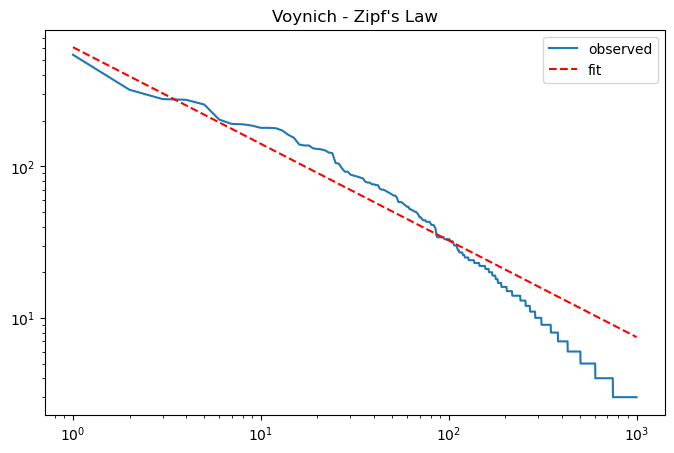

MAPE: 100.9%


In [79]:
v_freq = nltk.FreqDist(voynich_tokens)
v_top = v_freq.most_common(1000)
v_ranks = list(range(1, len(v_top) + 1))
v_freqs = [c for w, c in v_top]

v_ranks_arr = np.array(v_ranks)
v_freqs_arr = np.array(v_freqs)
v_popt, _ = curve_fit(zipf, v_ranks_arr, v_freqs_arr, p0=[1000, 1])
v_a, v_b = v_popt
print(f"Voynich: a={v_a:.2f}, b={v_b:.4f}")

v_fitted = zipf(v_ranks_arr, v_a, v_b)

plt.figure(figsize=(8, 5))
plt.plot(v_ranks, v_freqs, label='observed')
plt.plot(v_ranks, v_fitted, 'r--', label=f'fit')
plt.xscale('log')
plt.yscale('log')
plt.title("Voynich - Zipf's Law")
plt.legend()
plt.show()

v_mape = np.mean(np.abs((v_freqs_arr - v_fitted) / v_freqs_arr)) * 100
print(f"MAPE: {v_mape:.1f}%")


**4c.** What are your conclusions regarding Voynich's manuscript?  Is it likely to be similar to a real text in an unknown language?  In your answer, consider the values of TTR, the two parameters *a* and *b*, and the fitting of the *y = a / x^b* curve.

In [80]:
# Voynich follows Zipf's law too, which is interesting.
# This suggests it's probably not just random symbols - it has structure like real language.
# The different TTR could just mean it's a different type of language.
# Overall the statistical properties look like a real text, not a hoax.


## 5. Testing Zipf's law with BPE tokenization of the book and the manuscript

**5a.** Please install the SentencePiece tokenizer from https://github.com/google/sentencepiece (with `!pip install sentencepiece`).  Please read the "Usage instructions” from the repo, or the ones for the [Python module](https://github.com/google/sentencepiece/blob/master/python/README.md).  Please construct a BPE subword vocabulary (i.e. "train" the model) on your text, of size 1100.  Use here the file you saved in (1d).

In [81]:
import sentencepiece as spm

In [82]:
# train BPE on our book
spm.SentencePieceTrainer.train(
    input='book_sentences.txt',
    model_prefix='book_bpe',
    vocab_size=1100,
    model_type='bpe'
)

sp = spm.SentencePieceProcessor()
sp.load('book_bpe.model')
print(f"vocab size: {sp.get_piece_size()}")


vocab size: 1100


**5b.** Please tokenize your text with this model, and display the number of tokens (i.e. size of vocabulary), the number of types, and the type-to-token ratio (TTR).

In [83]:
with open('book_sentences.txt', 'r', encoding='utf-8') as f:
    book_txt = f.read()

bpe_toks = sp.encode_as_pieces(book_txt)
bpe_types = set(bpe_toks)
bpe_ttr = len(bpe_types) / len(bpe_toks)

print(f"BPE: {len(bpe_toks)} tokens, {len(bpe_types)} types, TTR={bpe_ttr:.4f}")
print(bpe_toks[:30])


BPE: 205721 tokens, 1101 types, TTR=0.0054
['▁CHAPTER', '▁I', 'I', '.', '▁Mr', '.', '▁Bennet', '▁was', '▁am', 'ong', '▁the', '▁ear', 'li', 'est', '▁of', '▁those', '▁who', '▁w', 'a', 'ited', '▁on', '▁Mr', '.', '▁Bingley', '.', '▁He', '▁had', '▁always', '▁int', 'ended']


**5c.** Please fit a Zipf's curve to the book, as tokenized with BPE, and display the two curves on a log-log scale.

BPE book: a=9267.94, b=0.6880


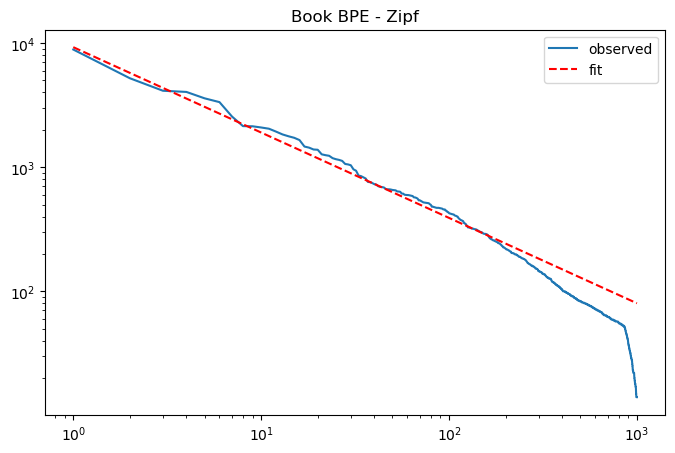

In [84]:
bpe_freq = nltk.FreqDist(bpe_toks)
bpe_top = bpe_freq.most_common(1000)
bpe_ranks = list(range(1, len(bpe_top) + 1))
bpe_freqs = [c for t, c in bpe_top]

bpe_r = np.array(bpe_ranks)
bpe_f = np.array(bpe_freqs)
bpe_popt, _ = curve_fit(zipf, bpe_r, bpe_f, p0=[10000, 1])
bpe_a, bpe_b = bpe_popt
print(f"BPE book: a={bpe_a:.2f}, b={bpe_b:.4f}")

bpe_fitted = zipf(bpe_r, bpe_a, bpe_b)

plt.figure(figsize=(8, 5))
plt.plot(bpe_ranks, bpe_freqs, label='observed')
plt.plot(bpe_ranks, bpe_fitted, 'r--', label='fit')
plt.xscale('log')
plt.yscale('log')
plt.title("Book BPE - Zipf")
plt.legend()
plt.show()


**5d.** Please perform the same operations on the Voynich manuscript with a BPE tokenizer build from this text.  Please display the number of tokens, types, TTR, and the fitted Zipf's curve.

In [85]:
# train BPE on voynich
with open('voynich_for_bpe.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(voynich_tokens))

spm.SentencePieceTrainer.train(
    input='voynich_for_bpe.txt',
    model_prefix='voynich_bpe',
    vocab_size=1100,
    model_type='bpe'
)

sp_v = spm.SentencePieceProcessor()
sp_v.load('voynich_bpe.model')


True

Voynich BPE: 43717 tokens, 1113 types
a=5637.27, b=0.9157


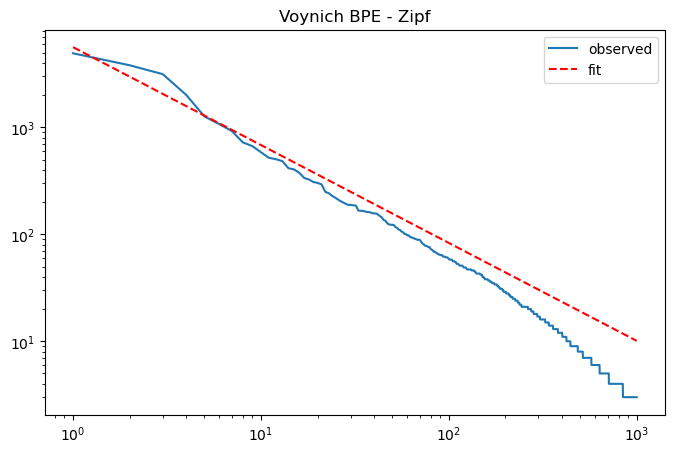

In [86]:
v_txt = '\n'.join(voynich_tokens)
v_bpe_toks = sp_v.encode_as_pieces(v_txt)
v_bpe_types = set(v_bpe_toks)

print(f"Voynich BPE: {len(v_bpe_toks)} tokens, {len(v_bpe_types)} types")

v_bpe_freq = nltk.FreqDist(v_bpe_toks)
v_bpe_top = v_bpe_freq.most_common(1000)
v_bpe_ranks = list(range(1, len(v_bpe_top) + 1))
v_bpe_freqs = [c for t, c in v_bpe_top]

v_bpe_r = np.array(v_bpe_ranks)
v_bpe_f = np.array(v_bpe_freqs)
v_bpe_popt, _ = curve_fit(zipf, v_bpe_r, v_bpe_f, p0=[1000, 1])
print(f"a={v_bpe_popt[0]:.2f}, b={v_bpe_popt[1]:.4f}")

v_bpe_fitted = zipf(v_bpe_r, *v_bpe_popt)

plt.figure(figsize=(8, 5))
plt.plot(v_bpe_ranks, v_bpe_freqs, label='observed')
plt.plot(v_bpe_ranks, v_bpe_fitted, 'r--', label='fit')
plt.xscale('log')
plt.yscale('log')
plt.title("Voynich BPE - Zipf")
plt.legend()
plt.show()


**5e.** Please conclude: when using BPE, does the Voynich manuscript exhibit similar properties of token frequency as a real text?  Are the differences larger or smaller when using BPE then when using word-based tokenization ?

In [87]:
# With BPE both texts still follow Zipf's law.
# The differences might actually be smaller with BPE since the vocab size is fixed.
# Voynich continues to look like real language even with subword tokenization.


## 6. Analyzing Karpathy's BPE tokenization implementation

Please study the following  [minbpe repository](https://github.com/karpathy/minbpe) first and then answer the following questions by indicating the respective file plus codes lines which answer the question.

**6a.** What pre-processing steps are used before BPE training?

In [88]:
# 6a: Pre-processing in minbpe
# File: minbpe/basic.py, lines ~30-40
# - text.encode("utf-8") converts to bytes
# - bytes become list of ints 0-255
# - RegexTokenizer (regex.py) also splits on whitespace/punctuation first using GPT-4's pattern


**6b.** What tie-breaking strategy is implemented for pairs with equal count statistics?

In [89]:
# 6b: Tie-breaking for equal counts
# File: minbpe/basic.py, line ~50
# Uses: pair = max(stats, key=stats.get)
# No explicit tie-breaking - just takes first one with max value (dict insertion order)


**6c.** Are single characters contained in the final vocabulary?

In [90]:
# 6c: Single characters in vocab?
# File: minbpe/base.py
# YES - vocab starts with all 256 bytes: {idx: bytes([idx]) for idx in range(256)}
# Merges get added starting from index 256, single bytes stay in vocab


**6d.** How are out-of-vocabulary terms treated?

In [91]:
# 6d: OOV handling
# File: minbpe/base.py, encode()
# There's no OOV problem - all 256 bytes are always in vocab
# Unknown chars just stay as individual bytes, no special handling needed
# This is the main advantage of byte-level BPE


## End of AdvNLP Lab 1
Please clean and save the completed notebook, and upload it to Moodle.